# 8. Visualization

In this tutorial, you will learn how to use the `astrometrics.visualization` registry to render two kinds of dashboard: one showing an entire target's field of stars, and one focused on a single star's light curve and spectrum.

## 8.1 The Target Dashboard

The target dashboard shows an entire field at once: the stacked FITS image with every identified star marked, alongside a panel that shows the selected star's light curve (if photometry has been run) or spectrum (if spectroscopy has been run).

Rendering target dashboard for M 13...


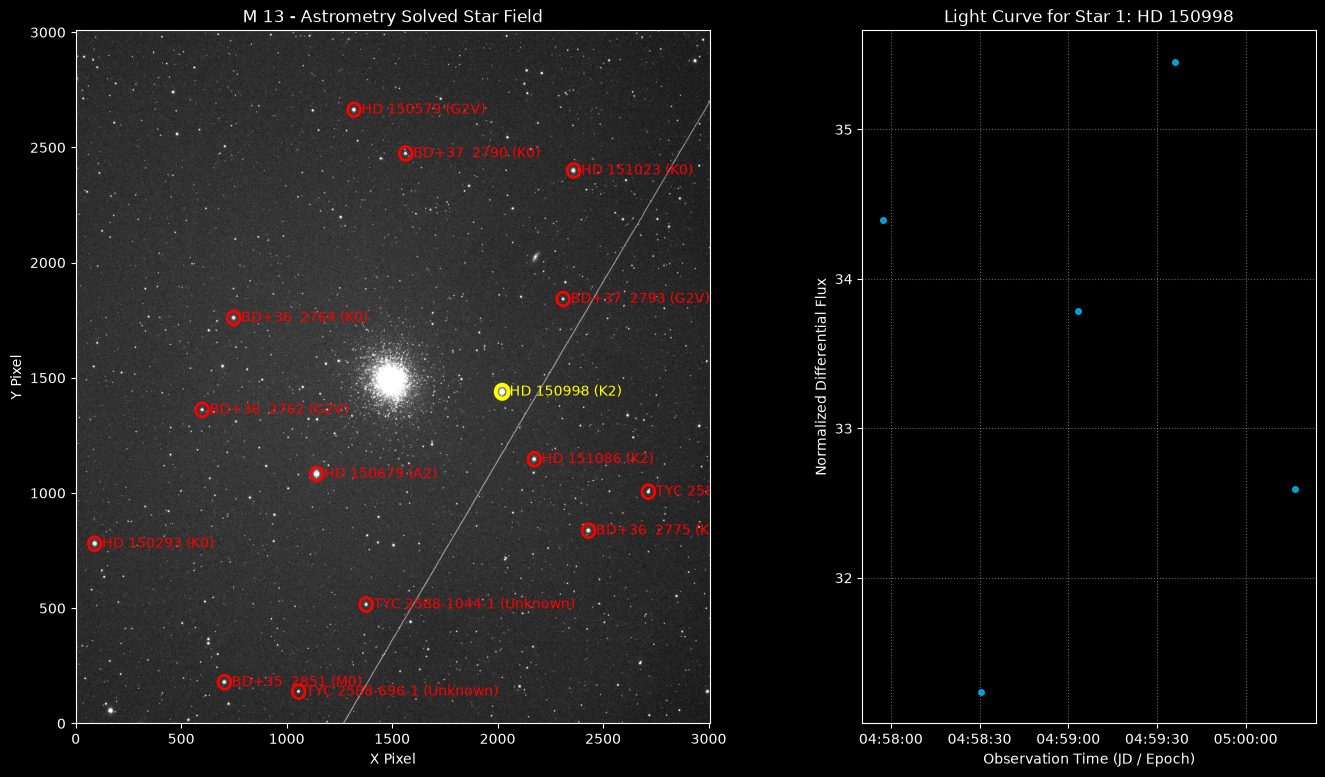

In [1]:
from astrometricslib import Astrometrics

astrometrics = Astrometrics()
target = astrometrics.targets.get("M 13")

print(f"Rendering target dashboard for {target.id}...")
target_figure = astrometrics.visualization.plot_target_dashboard(target)
target_figure.show()

## 8.2 The Star Dashboard

Where the target dashboard shows the whole field, the star dashboard zooms in on one star: its light curve and its calibrated spectrum, stacked in a single two-panel figure. Slitless spectroscopy extraction identifies zero-order star positions and registers their spectra under a corresponding `::spectroscopy` identifier (e.g. `HD 150998::spectroscopy`). `plot_star_dashboard()` can take this registered spectrum object as its second `spectral_star` argument alongside the photometric star object, displaying the light curve and spectrum side by side.

Rendering star dashboard for HD 150998...


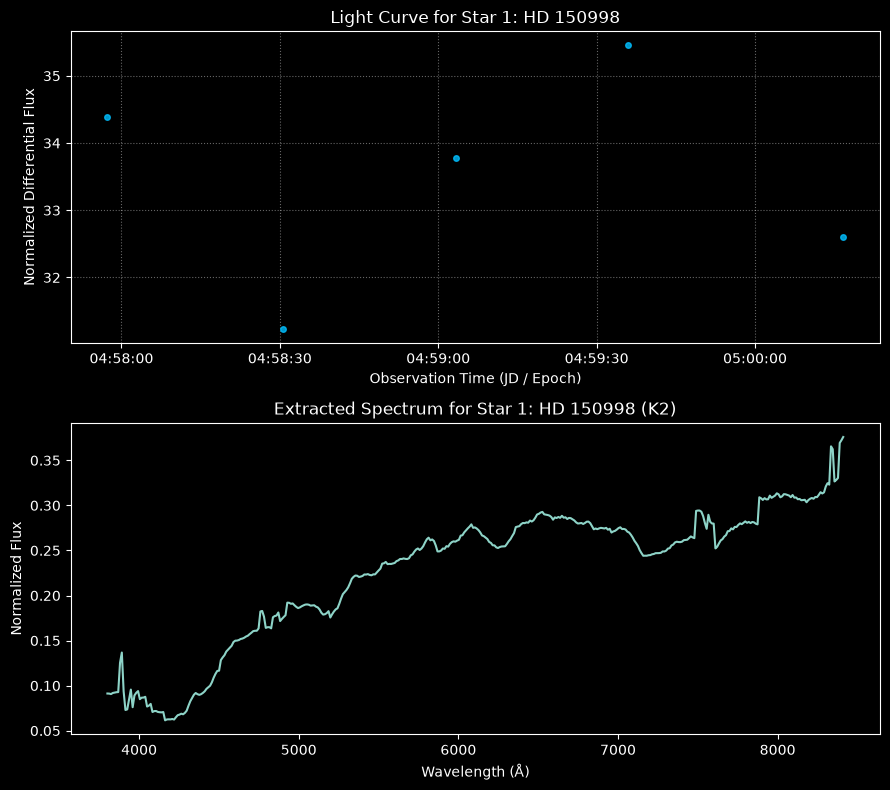

In [2]:
stellar_objects = [obj for obj in astrometrics.stars.list_objects() if target.id in obj.target_ids]

# Pick a star with an actual light curve, rather than just the first
# one found -- most identified stars in the field have no photometry,
# and a dashboard with an empty light-curve panel is not a useful demo.
star_with_light_curve = next(
    (
        candidate_star
        for candidate_star in stellar_objects
        if candidate_star.photometry and candidate_star.photometry.timestamps
    ),
    None,
)

if star_with_light_curve:
    spectral_star = astrometrics.stars.get_object(f"{star_with_light_curve.id}::spectroscopy")
    print(f"Rendering star dashboard for {star_with_light_curve.id}...")
    star_figure = astrometrics.visualization.plot_star_dashboard(
        star_with_light_curve, spectral_star=spectral_star
    )
    star_figure.show()
else:
    print("No star with light-curve data was found for this target; skipping the star dashboard.")